# ENVIRONMENT

In [1]:
!nvidia-smi
!lscpu
!free -h
!cat /etc/os-release
!df -h

Tue May 19 18:56:13 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.105.08             Driver Version: 580.105.08     CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   32C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

# LIBRARIES

In [2]:
import os
import gc
import json
import time
import copy
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator
from tqdm import tqdm
from sklearn.metrics import precision_recall_fscore_support
import albumentations as A
from albumentations.pytorch import ToTensorV2
from datetime import datetime

import timm
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, TensorDataset, DataLoader
torch.set_float32_matmul_precision('medium')

import pytorch_lightning as pl
from pytorch_lightning.callbacks import ModelCheckpoint, EarlyStopping, Callback
from pytorch_lightning.loggers import CSVLogger

import torchmetrics
from torchmetrics.classification import (
    MulticlassF1Score, MulticlassAccuracy, MulticlassPrecision, MulticlassRecall,
    BinaryF1Score, BinaryAccuracy, BinaryPrecision, BinaryRecall
)
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from huggingface_hub.utils import disable_progress_bars
disable_progress_bars()

SEED = 42
def set_seed(seed: int = 42) -> None:
    # Set a fixed value for the hash seed
    os.environ["PYTHONHASHSEED"] = str(seed)
    # Set seed for PyTorch
    torch.manual_seed(seed)
    # Set seed for CUDA (if using GPUs)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)  # For multi-GPU setups
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Set seed for Python's random module
    random.seed(seed)
    # Set seed for NumPy
    np.random.seed(seed)
    #tf.random.set_seed(seed) # set random seed for TensorFlow
    pl.seed_everything(seed, workers=True)
    print(f"[{datetime.now().strftime('%H:%M:%S')}] Seed set to {seed}")

In [3]:
!pip freeze > requirements.txt
set_seed(SEED)

Seed set to 42


[18:57:09] Seed set to 42


# UTILITIES

In [4]:
class NPZTextileDataset(Dataset):
    def __init__(self, X, transform=None):
        self.X = X
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        image = self.X[idx] # (H, W, 3)
        if self.transform:
            augmented = self.transform(image=image)
            image = augmented['image']
        return image

class TextileLightningModel(pl.LightningModule):
    def __init__(self, model_name, num_classes, experiment_type, class_weights=None, lr=1e-3):
        super().__init__()
        self.save_hyperparameters(ignore=['class_weights'])
        self.lr = lr
        
        # Carrega o modelo pre-treinado
        self.model = timm.create_model(model_name, pretrained=True, num_classes=num_classes, in_chans=3)
        
        # Define a Loss
        if experiment_type == "wce" and class_weights is not None:
            weights = torch.tensor(class_weights, dtype=torch.float32)
            self.criterion = nn.CrossEntropyLoss(weight=weights)
        elif experiment_type == "focal_loss" and class_weights is not None:
            self.criterion = MulticlassFocalLoss(alpha=class_weights, gamma=FL_GAMMA)
        else:
            self.criterion = nn.CrossEntropyLoss()
            
        # Métricas - Multiclasse (Ignorando 'good' para certas métricas se desejar, mas aqui usamos tudo macro)
        self.multi_f1 = MulticlassF1Score(num_classes=num_classes, average='macro')
        self.multi_acc = MulticlassAccuracy(num_classes=num_classes, average='micro')
        
        # Métricas - Binário (Defeito vs Good)
        self.bin_f1 = BinaryF1Score()
        self.bin_acc = BinaryAccuracy()

    def forward(self, x):
        return self.model(x)

    def training_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)
        self.log('train_loss', loss, on_step=False, on_epoch=True, prog_bar=True)
        return loss

    def validation_step(self, batch, batch_idx):
        inputs, labels = batch
        logits = self(inputs)
        loss = self.criterion(logits, labels)
        
        # Probs e Preds
        probs = torch.softmax(logits, dim=1)
        preds = torch.argmax(probs, dim=1)
        
        # Conversão Binária (0 = good, >0 = defeito)
        bin_labels = (labels > 0).long()
        bin_probs = probs[:, 1:].sum(dim=1)
        
        # Atualiza métricas
        self.multi_f1(preds, labels)
        self.multi_acc(preds, labels)
        self.bin_f1(bin_probs, bin_labels)
        self.bin_acc(bin_probs, bin_labels)
        
        self.log('val_loss', loss, prog_bar=True)
        self.log('val_f1_macro', self.multi_f1, on_epoch=True, prog_bar=True)
        self.log('val_acc_multi', self.multi_acc, on_epoch=True)
        self.log('val_f1_bin', self.bin_f1, on_epoch=True)
        self.log('val_acc_bin', self.bin_acc, on_epoch=True)

    def configure_optimizers(self):
        # AdamW é o padrão para modelos ViT e modernos do TIMM
        optimizer = optim.AdamW(self.parameters(), lr=self.lr, weight_decay=WEIGHT_DECAY)
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=self.trainer.max_epochs)
        return [optimizer], [scheduler]

def get_eval_transform(model_name):
    """Retorna apenas o transform de Eval (Resize + Normalize)"""
    temp_model = timm.create_model(model_name, pretrained=False, num_classes=0)
    data_config = timm.data.resolve_model_data_config(temp_model)
    mean, std = data_config['mean'], data_config['std']
    input_size = data_config['input_size'][-1]
    
    transform = A.Compose([
        A.Resize(input_size, input_size),
        A.Normalize(mean=mean, std=std),
        ToTensorV2()
    ])
    return transform, input_size

In [5]:
def calculate_f1_macro(y_true, y_pred):
    _, _, f1_mac, _ = precision_recall_fscore_support(y_true, y_pred, average='macro', zero_division=0)
    return round(f1_mac, 4)

def fast_pht(probs_grid: torch.Tensor, tau_1: float, tau_2: float) -> torch.Tensor:
    """
    Algoritmo PHT vetorizado.
    probs_grid: Tensor [H, W, C] (já na GPU)
    Classe 0 = Background
    """
    H, W, C = probs_grid.shape
    
    # -------------------------
    # Passo 1 — Semente (Tau 1)
    # -------------------------
    pred_conf, pred_class = torch.max(probs_grid, dim=2)
    final_map = pred_class.clone()

    mask_tau1 = (pred_class != 0) & (pred_conf < tau_1)
    final_map[mask_tau1] = 0

    # -------------------------
    # Passo 2 — Expansão (Tau 2)
    # -------------------------
    if tau_2 > 0:
        kernel = torch.ones((1, 1, 3, 3), device=probs_grid.device)
        changed = True

        while changed:
            prev_map = final_map.clone()

            for cls in range(1, C):
                class_mask = (final_map == cls).float().unsqueeze(0).unsqueeze(0)
                dilated = F.conv2d(class_mask, kernel, padding=1) > 0
                
                grow_mask = (final_map == 0) & dilated.squeeze() & (probs_grid[..., cls] > tau_2)
                final_map[grow_mask] = cls

            changed = not torch.equal(prev_map, final_map)

    return final_map

def prepare_spatial_cache(cache_df: pd.DataFrame, num_classes: int, device='cuda') -> list:
    """
    Converte o DataFrame tabular em uma lista de grades espaciais na GPU.
    Deve ser chamado apenas UMA VEZ por Fold.
    """
    if not torch.cuda.is_available() and device == 'cuda':
        device = 'cpu'
        
    # Encontra a distância real entre os patches (ex: 64px)
    unique_x = np.sort(np.unique(cache_df['x'].values))
    unique_y = np.sort(np.unique(cache_df['y'].values))
    dx = unique_x[1] - unique_x[0] if len(unique_x) > 1 else 1 
    dy = unique_y[1] - unique_y[0] if len(unique_y) > 1 else 1
    
    prob_cols = [f'prob_class_{i}' for i in range(num_classes)]
    spatial_list = []
    
    # Processa imagem por imagem
    for group_id, group_df in cache_df.groupby('group_id'):
        xs = group_df['x'].values
        ys = group_df['y'].values
        
        # Otimização: A grade [H,W] precisa apenas do tamanho exato da imagem local
        min_x, min_y = xs.min(), ys.min()
        col_idx = ((xs - min_x) / dx).astype(int)
        row_idx = ((ys - min_y) / dy).astype(int)
        
        W = col_idx.max() + 1
        H = row_idx.max() + 1
        
        # Cria e preenche a grade de probabilidades na GPU
        probs_grid = torch.zeros((H, W, num_classes), device=device, dtype=torch.float32)
        probs_vals = torch.tensor(group_df[prob_cols].values, device=device, dtype=torch.float32)
        probs_grid[row_idx, col_idx] = probs_vals
        
        # Salva o "pacote" espacial para esta imagem
        spatial_list.append({
            'group_id': group_id,
            'probs_grid': probs_grid,
            'row_idx': row_idx,
            'col_idx': col_idx,
            'indices': group_df.index.values # Importante para mapear de volta à tabela
        })
        
    return spatial_list

def apply_pht_fast(spatial_cache: list, total_patches: int, tau_1: float, tau_2: float) -> np.ndarray:
    """
    Roda o PHT em cima do cache espacial pré-processado e remonta o array 1D.
    """
    final_predictions = np.zeros(total_patches, dtype=int)
    
    for item in spatial_cache:
        # A magia acontece aqui na GPU
        final_map = fast_pht(item['probs_grid'], tau_1, tau_2)
        
        # Mapeia a grade 2D de volta para as posições reais da matriz 1D
        preds_1d = final_map[item['row_idx'], item['col_idx']].cpu().numpy()
        final_predictions[item['indices']] = preds_1d
        
    return final_predictions

def count_pht_collisions(cache_df, tau_1, tau_2, num_classes):
    """Conta quantos patches recebem propostas simultâneas de expansão."""
    total_patches = len(cache_df)
    colliding_patches = 0
    prob_cols = [f'prob_class_{i}' for i in range(num_classes)]
    grouped = cache_df.groupby('group_id')
    
    for group_id, group in grouped:
        group = group.sort_values(['y', 'x'])
        preds = group['pred_raw'].values.copy()
        confs = group['pred_conf'].values
        probs = group[prob_cols].values
        coords = list(zip(group['x'].values, group['y'].values))
        coord_to_idx = {c: i for i, c in enumerate(coords)}
        
        mask_defect = preds != 0
        preds[mask_defect & (confs < tau_1)] = 0
        claimants = [set() if p == 0 else {p} for p in preds]
        
        if tau_2 > 0:
            expanded = True
            while expanded:
                expanded = False
                for i, (px, py) in enumerate(coords):
                    current_classes = claimants[i]
                    if len(current_classes) == 0: continue
                    for nx in (px-1, px, px+1):
                        for ny in (py-1, py, py+1):
                            if (nx, ny) == (px, py): continue
                            neighbor = (nx, ny)
                            if neighbor in coord_to_idx:
                                j = coord_to_idx[neighbor]
                                if preds[j] == 0:
                                    for c in current_classes:
                                        if c != 0 and probs[j, c] > tau_2:
                                            if c not in claimants[j]:
                                                claimants[j].add(c)
                                                expanded = True
                                                
        for claims in claimants:
            if len(claims) > 1: colliding_patches += 1
                
    return colliding_patches, total_patches

def run_inference_on_npz(npz_path, model_path, model_name, device='cuda', batch_size=256):
    """Lê o NPZ, carrega o modelo, descobre num_classes e gera o Cache."""
    
    # 1. Carrega os dados nativos do NPZ
    data = np.load(npz_path)
    X = data['X']               
    y_multi = data['y_multi']
    groups = data['groups']
    coords = data['coords']
    
    if X.ndim == 3: 
        X = np.stack([X]*3, axis=-1)
    
    transform, _ = get_eval_transform(model_name)
    dataset = NPZTextileDataset(X, transform=transform)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=False, num_workers=4)
    
    # 2. Carrega o Modelo
    model = TextileLightningModel.load_from_checkpoint(model_path, map_location=device)
    model.eval()
    model.to(device)
    
    num_classes = getattr(model.hparams, 'num_classes', None)
    if num_classes is None:
        num_classes = model.model.num_classes  # Propriedade nativa do timm
    
    # 3. Extração de Probabilidades
    all_probs = []
    with torch.no_grad():
        for batch_images in tqdm(loader, desc="Extraindo Probabilidades", leave=False):
            batch_images = batch_images.to(device)
            logits = model(batch_images)
            probs = torch.softmax(logits, dim=1).cpu().numpy()
            all_probs.append(probs)
            
    all_probs = np.vstack(all_probs)
    preds_raw = np.argmax(all_probs, axis=1)
    preds_conf = np.max(all_probs, axis=1)

    # 4. Montagem do Cache
    cache_df = pd.DataFrame({
        'group_id': groups,
        'y': coords[:, 0],       
        'x': coords[:, 1],       
        'multi_target': y_multi,
        'pred_raw': preds_raw,
        'pred_conf': preds_conf
    })
    
    for i in range(num_classes):
        cache_df[f'prob_class_{i}'] = all_probs[:, i]
        
    # Retornamos o DataFrame E o número de classes detectado no modelo
    return cache_df, num_classes

def run_pht_grid_search(
    dataset_name: str,
    patch_size: int,
    timm_model_name: str,
    undersampling_ratio: int = 1,
    tau_range: np.ndarray = np.arange(0.50, 0.96, 0.05),
    batch_size: int = 256,
    device: str = None,
    npz_base_path: str = '/kaggle/input/datasets/angelogoes/tilda-hku-patched-dataset',
    model_base_path: str = '/kaggle/input/datasets/angelogoes/hku-tilda-mnet3-und1-p64'
):
    if device is None:
        device = 'cuda' if torch.cuda.is_available() else 'cpu'

    fold_matrices = []
    validation_caches = []
    fold_baselines = []
    detected_num_classes = None # Será preenchido dinamicamente

    # Calcula o total exato de iterações válidas (Matriz Triangular onde t2 <= t1)
    total_combinacoes = sum(1 for t1 in tau_range for t2 in tau_range if t2 <= t1)

    for fold in range(5):
        print(f"\n---> Processando Fold {fold} <---")
        
        npz_dir_name = f"npz_{dataset_name.lower()}_{patch_size}"
        npz_path = f"{npz_base_path}/{npz_dir_name}/Fold_{fold}_val.npz"
        
        model_dir_name = f"{dataset_name.upper()}_{patch_size}_undersampling_ratio{undersampling_ratio}_{timm_model_name}"
        model_path = f"{model_base_path}/{model_dir_name}/fold_{fold}_best.ckpt"
        
        # Chamada atualizada (retorna df e a quantidade de classes do modelo)
        cache_df, num_classes = run_inference_on_npz(
            npz_path=npz_path, 
            model_path=model_path, 
            model_name=timm_model_name, 
            device=device,
            batch_size=batch_size
        )

        # === NOVO: Cálculo do Baseline F1 (Sem PHT) ===
        baseline_f1 = calculate_f1_macro(cache_df['multi_target'].values, cache_df['pred_raw'].values)
        fold_baselines.append(baseline_f1)
        # ===============================================
        
        # Guarda o num_classes do primeiro fold para exibir no print final
        if detected_num_classes is None:
            detected_num_classes = num_classes
            print(f"[INFO] Classes detectadas no checkpoint: {detected_num_classes}")

        print(f"[INFO] Baseline F1 Macro (Sem PHT): {baseline_f1:.4f}")
        
        # === A GRANDE OTIMIZAÇÃO AQUI ===
        # Passa todos os dados do fold para a GPU no formato espacial ideal
        spatial_cache = prepare_spatial_cache(cache_df, num_classes, device)
        total_patches_in_fold = len(cache_df)
        
        matrix = np.full((len(tau_range), len(tau_range)), np.nan)
        print(f"-> Executando Grid Search PHT (Fold {fold})...")
        
        with tqdm(total=total_combinacoes, desc=f"Avaliando Taus (Fold {fold})", leave=False) as pbar:
            for i, t1 in enumerate(tau_range):
                for j, t2 in enumerate(tau_range):
                    if t2 <= t1:
                        t1_r, t2_r = round(t1, 3), round(t2, 3)
                        
                        # Chama a nova função ultra-rápida
                        pht_preds = apply_pht_fast(spatial_cache, total_patches_in_fold, t1_r, t2_r)
                        
                        # O multi_target.values não muda de ordem, o cálculo de métricas segue igual
                        matrix[i, j] = calculate_f1_macro(cache_df['multi_target'].values, pht_preds)
                        pbar.update(1)
                    
        fold_matrices.append(matrix)
        validation_caches.append(cache_df)

    # Média do Consenso
    consensus_matrix = np.nanmean(fold_matrices, axis=0)
    consensus_baseline = np.mean(fold_baselines)
    
    max_idx = np.unravel_index(np.nanargmax(consensus_matrix), consensus_matrix.shape)
    best_t1_global = round(tau_range[max_idx[0]], 3)
    best_t2_global = round(tau_range[max_idx[1]], 3)

    print(f"\n[SUCESSO] Consenso Encontrado para {detected_num_classes} classes!")
    print(f"Melhor Par Global -> tau_1: {best_t1_global:.2f}, tau_2: {best_t2_global:.2f}")
    
    return {
        'best_tau_1': best_t1_global,
        'best_tau_2': best_t2_global,
        'consensus_matrix': consensus_matrix,
        'fold_matrices': fold_matrices,
        'validation_caches': validation_caches,
        'tau_range': tau_range,
        'num_classes': detected_num_classes,
        'fold_baselines': fold_baselines,
        'consensus_baseline': consensus_baseline
    }

def plot_pht_grid_results(
    fold_matrices: list, 
    consensus_matrix: np.ndarray, 
    tau_range: np.ndarray, 
    fold_baselines: list = None,       
    consensus_baseline: float = None,  
    dataset_name: str = "", 
    model_name: str = "", 
    figsize: tuple = (20, 12),
    cmap: str = "gist_rainbow"
):
    fig, axes = plt.subplots(2, 3, figsize=figsize)
    axes = axes.flatten()

    def draw_annotation(ax, matrix, tau_range, baseline=None):
        if np.all(np.isnan(matrix)): 
            return 
            
        idx = np.unravel_index(np.nanargmax(matrix), matrix.shape)
        row, col = idx
        val_th = tau_range[row]
        val_tl = tau_range[col]
        max_val = matrix[idx]
        
        rect = plt.Rectangle((col, row), 1, 1, fill=False, edgecolor='red', lw=3)
        ax.add_patch(rect)
        
        delta_str = ""
        if baseline is not None:
            delta = max_val - baseline
            sinal = "+" if delta > 0 else ""
            delta_str = f"\n$\\Delta$: {sinal}{delta:.3f}"
        
        text_str = f"$\\tau_h$: {val_th:.2f}, $\\tau_l$: {val_tl:.2f}\nF1: {max_val:.3f}{delta_str}"
        ax.text(0.95, 0.05, text_str, 
                transform=ax.transAxes, 
                ha='right', va='bottom', 
                color='black', 
                fontsize=16, 
                bbox=dict(boxstyle="square,pad=0.5", fc="white", ec="red", alpha=0.9, lw=2))

    # =========================================================================
    # NOVA LÓGICA AUTOMÁTICA DE TICKS: 
    # Encontra apenas os índices exatos que caem em múltiplos de 0.1
    # =========================================================================
    tick_positions = []
    tick_labels = []
    for idx, val in enumerate(tau_range):
        if np.isclose(val * 10, np.round(val * 10)):
            tick_positions.append(idx + 0.5) # O +0.5 alinha perfeitamente no centro da célula
            tick_labels.append(f"{val:.2f}")

    if dataset_name or model_name:
        title_str = f"PHT Optimization Grid"
        if dataset_name: title_str += f" - {dataset_name.upper()}"
        if model_name: title_str += f" ({model_name})"
        fig.suptitle(title_str, fontsize=22, y=0.98)

    # Plot Folds 0 a 4
    for i in range(5):
        # Removemos os xticklabels e yticklabels daqui
        sns.heatmap(fold_matrices[i], annot=False, cmap=cmap, ax=axes[i], cbar=True)
        
        axes[i].invert_yaxis()
        
        # Aplicamos os ticks e labels calculados automaticamente
        axes[i].set_xticks(tick_positions)
        axes[i].set_xticklabels(tick_labels)
        axes[i].set_yticks(tick_positions)
        axes[i].set_yticklabels(tick_labels)
        
        base_str = f" | Base: {fold_baselines[i]:.3f}" if fold_baselines else ""
        axes[i].set_title(f"Fold {i} (Val){base_str}", fontsize=18, pad=10)
        axes[i].set_xlabel(r"$\tau_{low}$", fontsize=18)
        axes[i].set_ylabel(r"$\tau_{high}$", fontsize=18)
        
        axes[i].tick_params(axis='x', rotation=45, labelsize=14)
        axes[i].tick_params(axis='y', rotation=0, labelsize=14)
        axes[i].collections[0].colorbar.ax.tick_params(labelsize=14)
        
        draw_annotation(axes[i], fold_matrices[i], tau_range, baseline=(fold_baselines[i] if fold_baselines else None))

    # Plot do Consenso
    sns.heatmap(consensus_matrix, annot=False, cmap=cmap, ax=axes[5], cbar=True)
    
    axes[5].invert_yaxis()
    
    # Aplicamos os ticks calculados no consenso também
    axes[5].set_xticks(tick_positions)
    axes[5].set_xticklabels(tick_labels)
    axes[5].set_yticks(tick_positions)
    axes[5].set_yticklabels(tick_labels)
    
    base_str_cons = f" | Base: {consensus_baseline:.3f}" if consensus_baseline else ""
    axes[5].set_title(f"Mean{base_str_cons}", fontsize=18, pad=10)
    axes[5].set_xlabel(r"$\tau_{low}$", fontsize=18)
    axes[5].set_ylabel(r"$\tau_{high}$", fontsize=18)
    
    axes[5].tick_params(axis='x', rotation=45, labelsize=14)
    axes[5].tick_params(axis='y', rotation=0, labelsize=14)
    axes[5].collections[0].colorbar.ax.tick_params(labelsize=14)
    
    draw_annotation(axes[5], consensus_matrix, tau_range, baseline=consensus_baseline)

    plt.tight_layout()
    if dataset_name or model_name:
        plt.subplots_adjust(top=0.91)
        
    plt.show()

def run_pht_collision_diagnostic(
    validation_caches: list, 
    best_t1: float, 
    best_t2: float, 
    num_classes: int
):
    """
    Calcula e imprime o relatório de colisões espaciais do PHT para todos os folds,
    consolidando a média global de conflitos de expansão.
    
    Parâmetros:
    - validation_caches: Lista de DataFrames de cache gerados na inferência (um por fold).
    - best_t1: Valor ótimo de tau_1 (Seed) encontrado pelo Grid Search.
    - best_t2: Valor ótimo de tau_2 (Expansion) encontrado pelo Grid Search.
    - num_classes: Quantidade de classes do modelo.
    """
    print("\n" + "="*60)
    print(f"=== DIAGNÓSTICO BRUTO DE COLISÃO DO PHT ===")
    print(f"Parâmetros aplicados: tau_1 = {best_t1:.3f} | tau_2 = {best_t2:.3f}")
    print("="*60)

    total_colisoes = 0
    total_patches_gerais = 0
    fold_details = []

    for fold, cache_df in enumerate(validation_caches):
        # Executa a sua função interna de contagem de colisões
        colisoes, total = count_pht_collisions(cache_df, best_t1, best_t2, num_classes)
        taxa = (colisoes / total) * 100 if total > 0 else 0
        
        total_colisoes += colisoes
        total_patches_gerais += total
        
        print(f"Fold {fold}: {colisoes} colisões em {total} patches ({taxa:.4f}%)")
        
        fold_details.append({
            'fold': fold,
            'colisoes': colisoes,
            'total_patches': total,
            'taxa_colisao': taxa
        })

    taxa_global = (total_colisoes / total_patches_gerais) * 100 if total_patches_gerais > 0 else 0

    print("-" * 60)
    print(f"MÉDIA GLOBAL: {total_colisoes} colisões totais ({taxa_global:.4f}%)")
    print("="*60)
    
    # Retorna o sumário estruturado caso precise registrar em tabelas/arquivos
    return {
        'total_collisions': total_colisoes,
        'total_patches': total_patches_gerais,
        'global_rate': taxa_global,
        'folds': fold_details
    }

# GRID SEARCH OPTIMIZATION


---> Processando Fold 0 <---


[INFO] Classes detectadas no checkpoint: 7
[INFO] Baseline F1 Macro (Sem PHT): 0.6611
-> Executando Grid Search PHT (Fold 0)...



---> Processando Fold 1 <---


[INFO] Baseline F1 Macro (Sem PHT): 0.7280
-> Executando Grid Search PHT (Fold 1)...



---> Processando Fold 2 <---


...

[INFO] Baseline F1 Macro (Sem PHT): 0.4412
-> Executando Grid Search PHT (Fold 3)...



---> Processando Fold 4 <---


[INFO] Baseline F1 Macro (Sem PHT): 0.5190
-> Executando Grid Search PHT (Fold 4)...


/tmp/ipykernel_23/3308200143.py:281: RuntimeWarning: Mean of empty slice
  consensus_matrix = np.nanmean(fold_matrices, axis=0)



[SUCESSO] Consenso Encontrado para 7 classes!
Melhor Par Global -> tau_1: 0.38, tau_2: 0.21


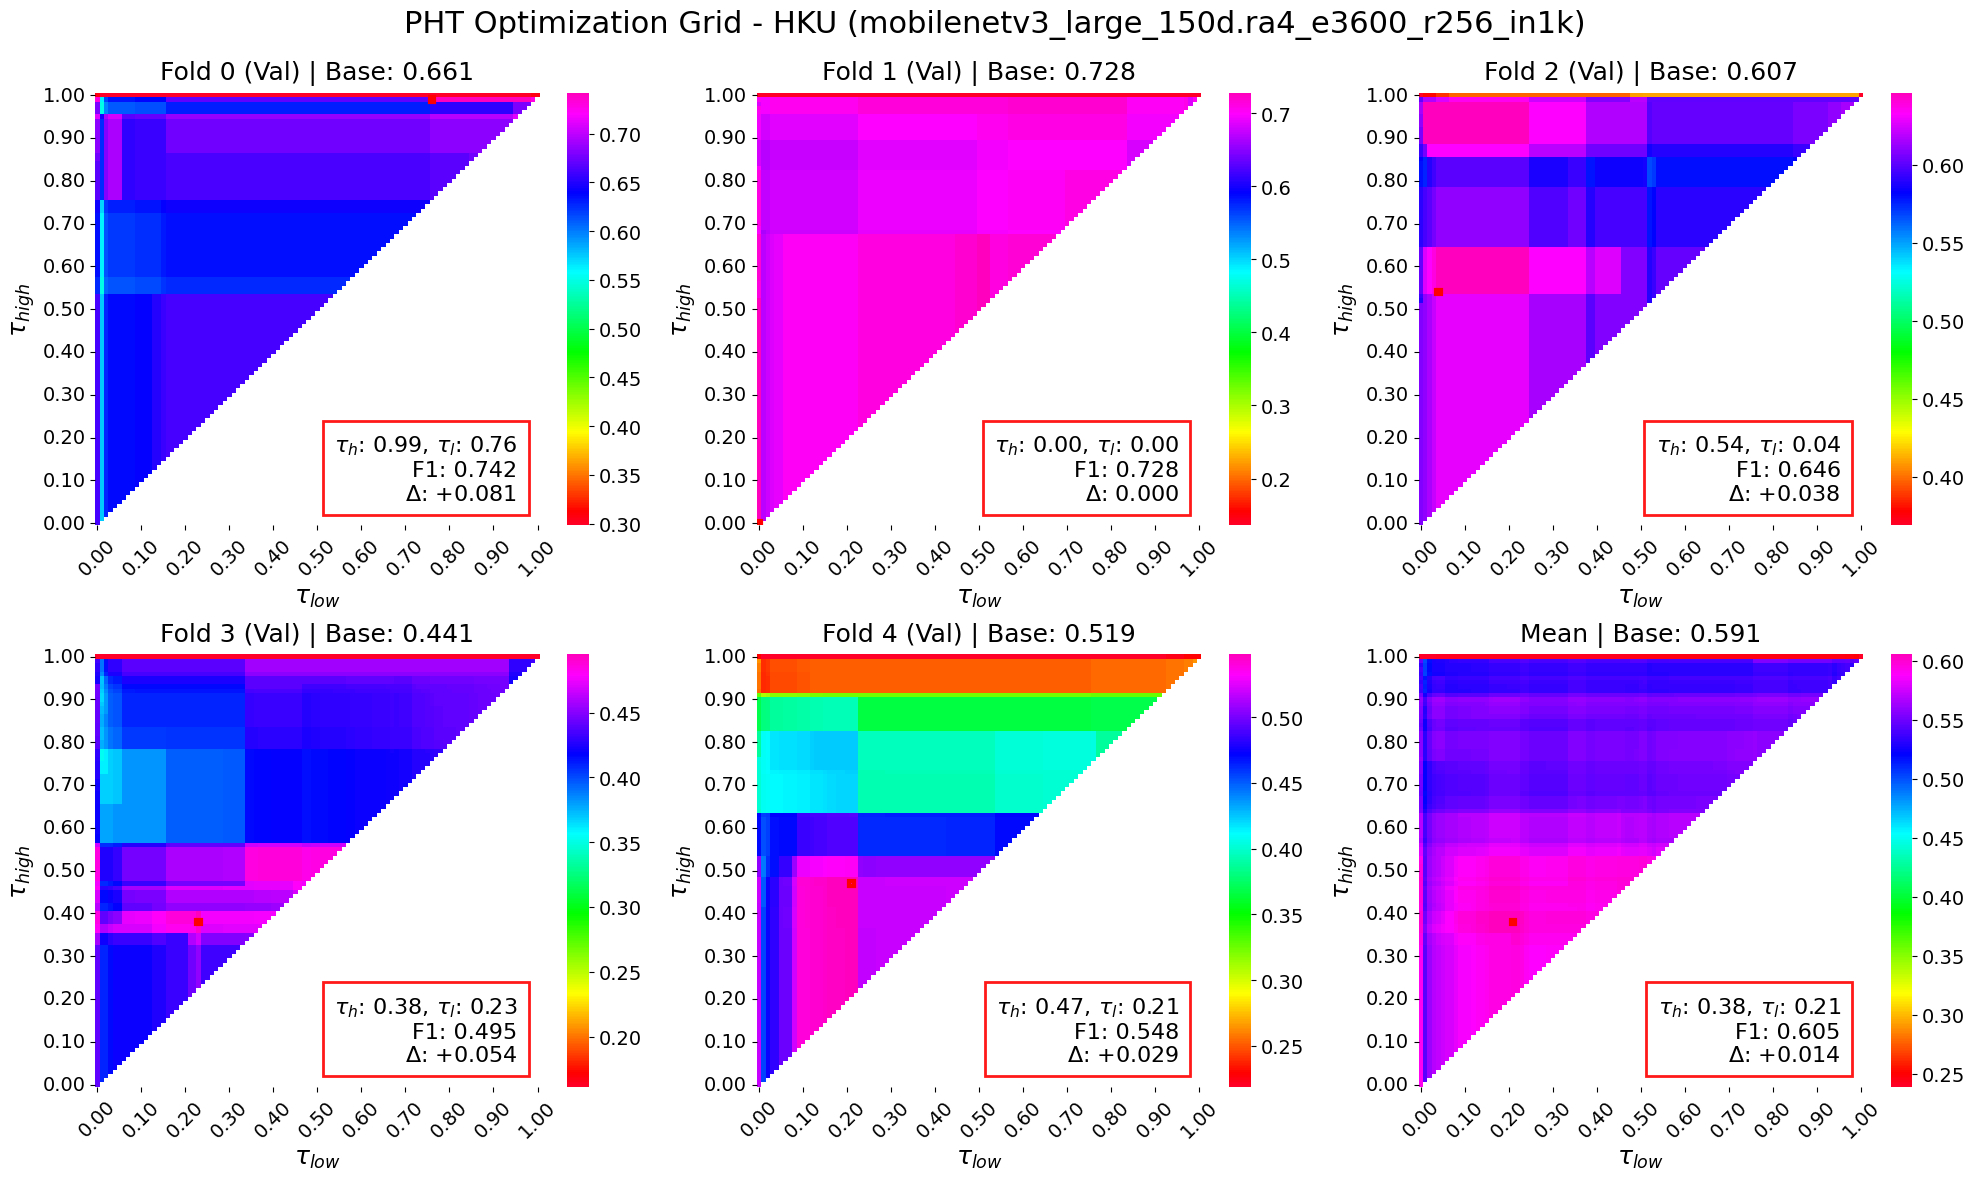


=== DIAGNÓSTICO BRUTO DE COLISÃO DO PHT ===
Parâmetros aplicados: tau_1 = 0.380 | tau_2 = 0.210
Fold 0: 0 colisões em 416 patches (0.0000%)
Fold 1: 0 colisões em 416 patches (0.0000%)
Fold 2: 0 colisões em 416 patches (0.0000%)
Fold 3: 0 colisões em 400 patches (0.0000%)
Fold 4: 0 colisões em 400 patches (0.0000%)
------------------------------------------------------------
MÉDIA GLOBAL: 0 colisões totais (0.0000%)


{'total_collisions': 0,
 'total_patches': 2048,
 'global_rate': 0.0,
 'folds': [{'fold': 0,
   'colisoes': 0,
   'total_patches': 416,
   'taxa_colisao': 0.0},
  {'fold': 1, 'colisoes': 0, 'total_patches': 416, 'taxa_colisao': 0.0},
  {'fold': 2, 'colisoes': 0, 'total_patches': 416, 'taxa_colisao': 0.0},
  {'fold': 3, 'colisoes': 0, 'total_patches': 400, 'taxa_colisao': 0.0},
  {'fold': 4, 'colisoes': 0, 'total_patches': 400, 'taxa_colisao': 0.0}]}

In [6]:
dataset_name = "HKU"
patch_size = 64
timm_model_name = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
tau_range = np.arange(0.00, 1.01, 0.01)

results = run_pht_grid_search(
    dataset_name=dataset_name,
    patch_size=patch_size,
    timm_model_name=timm_model_name,
    tau_range=tau_range,
)

plot_pht_grid_results(
    fold_matrices=results['fold_matrices'],
    consensus_matrix=results['consensus_matrix'],
    tau_range=results['tau_range'],
    fold_baselines=results.get('fold_baselines'),
    consensus_baseline=results.get('consensus_baseline'),
    dataset_name=dataset_name,
    model_name=timm_model_name,
    cmap="gist_rainbow"
)

run_pht_collision_diagnostic(
    validation_caches=results['validation_caches'],
    best_t1=results['best_tau_1'],
    best_t2=results['best_tau_2'],
    num_classes=results['num_classes']
)


---> Processando Fold 0 <---


[INFO] Classes detectadas no checkpoint: 5
[INFO] Baseline F1 Macro (Sem PHT): 0.7183
-> Executando Grid Search PHT (Fold 0)...



---> Processando Fold 1 <---


[INFO] Baseline F1 Macro (Sem PHT): 0.7253
-> Executando Grid Search PHT (Fold 1)...



---> Processando Fold 2 <---


...

[INFO] Baseline F1 Macro (Sem PHT): 0.7377
-> Executando Grid Search PHT (Fold 3)...



---> Processando Fold 4 <---


[INFO] Baseline F1 Macro (Sem PHT): 0.7581
-> Executando Grid Search PHT (Fold 4)...


/tmp/ipykernel_23/3308200143.py:281: RuntimeWarning: Mean of empty slice
  consensus_matrix = np.nanmean(fold_matrices, axis=0)



[SUCESSO] Consenso Encontrado para 5 classes!
Melhor Par Global -> tau_1: 0.90, tau_2: 0.56


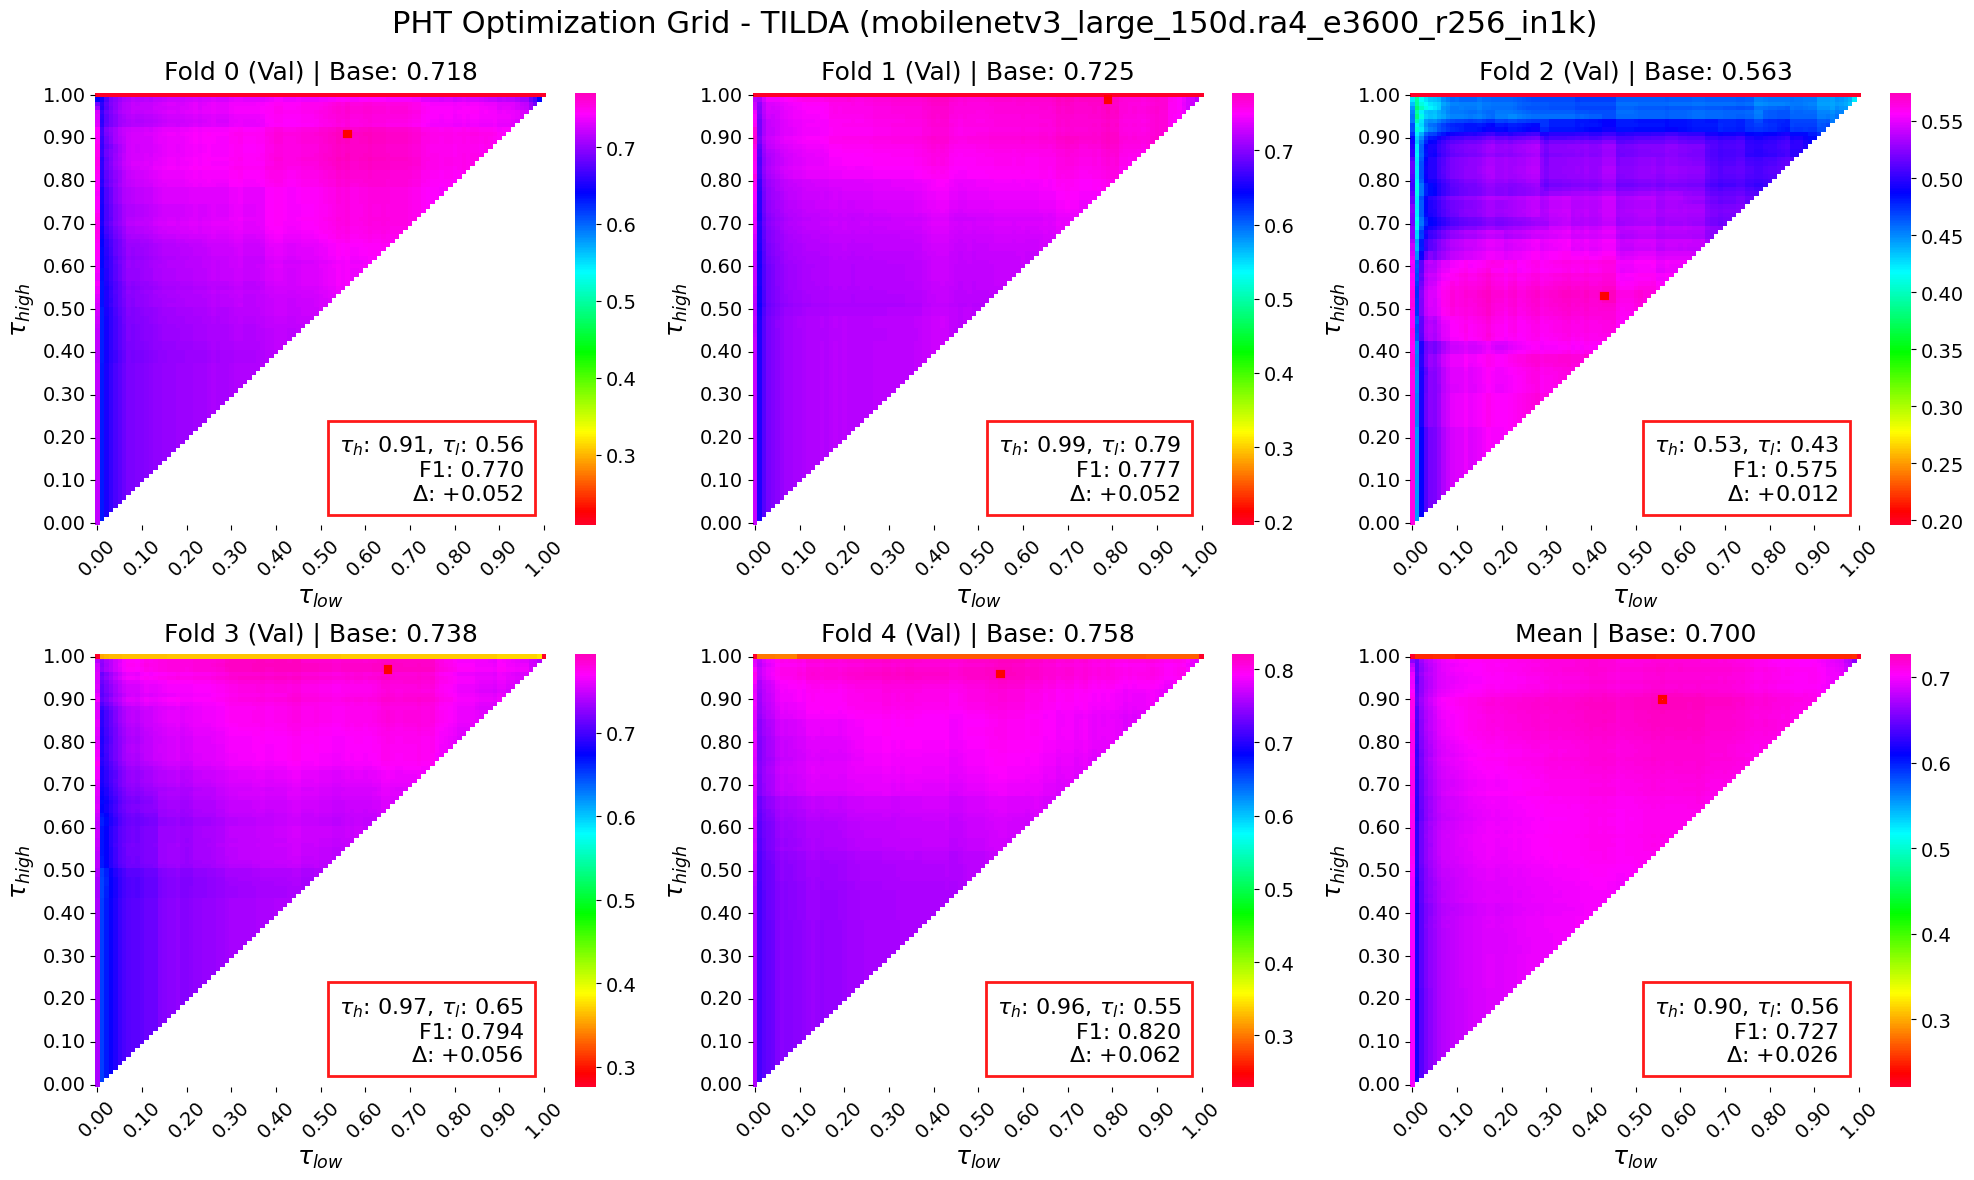


=== DIAGNÓSTICO BRUTO DE COLISÃO DO PHT ===
Parâmetros aplicados: tau_1 = 0.900 | tau_2 = 0.560
Fold 0: 0 colisões em 6144 patches (0.0000%)
Fold 1: 0 colisões em 6144 patches (0.0000%)
Fold 2: 0 colisões em 6144 patches (0.0000%)
Fold 3: 0 colisões em 6144 patches (0.0000%)
Fold 4: 0 colisões em 6144 patches (0.0000%)
------------------------------------------------------------
MÉDIA GLOBAL: 0 colisões totais (0.0000%)


{'total_collisions': 0,
 'total_patches': 30720,
 'global_rate': 0.0,
 'folds': [{'fold': 0,
   'colisoes': 0,
   'total_patches': 6144,
   'taxa_colisao': 0.0},
  {'fold': 1, 'colisoes': 0, 'total_patches': 6144, 'taxa_colisao': 0.0},
  {'fold': 2, 'colisoes': 0, 'total_patches': 6144, 'taxa_colisao': 0.0},
  {'fold': 3, 'colisoes': 0, 'total_patches': 6144, 'taxa_colisao': 0.0},
  {'fold': 4, 'colisoes': 0, 'total_patches': 6144, 'taxa_colisao': 0.0}]}

In [7]:
dataset_name = "TILDA"
patch_size = 64
timm_model_name = "mobilenetv3_large_150d.ra4_e3600_r256_in1k"
tau_range = np.arange(0.00, 1.01, 0.01)

results = run_pht_grid_search(
    dataset_name=dataset_name,
    patch_size=patch_size,
    timm_model_name=timm_model_name,
    tau_range=tau_range,
)

plot_pht_grid_results(
    fold_matrices=results['fold_matrices'],
    consensus_matrix=results['consensus_matrix'],
    tau_range=results['tau_range'],
    fold_baselines=results.get('fold_baselines'),
    consensus_baseline=results.get('consensus_baseline'),
    dataset_name=dataset_name,
    model_name=timm_model_name,
    cmap="gist_rainbow"
)

run_pht_collision_diagnostic(
    validation_caches=results['validation_caches'],
    best_t1=results['best_tau_1'],
    best_t2=results['best_tau_2'],
    num_classes=results['num_classes']
)